# Task Overview

As the 2026 NFL Draft kicks off in Green Bay, let's investigate one of the most debated questions in football: are high draft picks actually worth it? With teams, such as the New York Giants, trading a top-tier for a single first-round pick, the stakes of drafting well have never been higher. We will analyze 20 years of NFL draft data (2005–2024) to determine whether draft position truly predicts player success — and which franchises have made the most (and least) of their selections. The following exercises will:

- Cleanse and standardize NFL draft and player performance data
- Explore how draft position correlates with career performance across positions
- Identify where "draft value" drop-offs occur (e.g., does pick #1 really outperform pick #15?)
- Determine which NFL teams have historically drafted above or below expectations
- Determine which NFL position is most likely to be a "bust"
- Evaluate whether the data supports the idea that top picks are worth the hype

## Imports and Setup

We begin by importing the libraries we'll use throughout this notebook:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for visualization

No external connections are required — all data files are stored locally alongside this notebook.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default plot style for consistent visuals throughout the notebook
sns.set_theme(style="whitegrid")

## Loading the Data

We load one CSV file per draft year (2005–2024) from Pro Football Reference.
Each file contains all picks from that year, including player name, position,
team, pick number, and career Approximate Value (AV) — PFR's composite
metric for evaluating player career performance across all positions.

We combine all 20 files into a single DataFrame and add a `draft_year` column
so we can track which year each player was drafted.


In [10]:
# List of all draft years we're analyzing
years = list(range(2005, 2025))

dfs = []
for year in years:
    df = pd.read_csv(f'draft_{year}.csv', skiprows=1)
    df['draft_year'] = year
    dfs.append(df)

draft_df = pd.concat(dfs, ignore_index=True)

# Remove repeated header rows that PFR inserts every 30 rows
draft_df = draft_df[draft_df['Rnd'] != 'Rnd']

# Drop the artifact '-9999' column that PFR adds at the end of every CSV
draft_df = draft_df.drop(columns=['-9999'], errors='ignore')

print(f"Total draft picks loaded: {len(draft_df)}")
draft_df.head()

Total draft picks loaded: 5109


,Rnd,Pick,Tm,Player,Pos,Age,To,AP1,PB,St,...,TD.1,Rec,Yds.2,TD.2,Solo,Int.1,Sk,College/Univ,Unnamed: 28,draft_year
0,1,1,SFO,Alex Smith,QB,21.0,2020.0,0,3,14,...,15.0,3.0,-7.0,0.0,NaN,NaN,NaN,Utah,College Stats,2005
1,1,2,MIA,Ronnie Brown,RB,23.0,2014.0,0,1,6,...,38.0,246.0,1966.0,2.0,1.0,NaN,NaN,Auburn,College Stats,2005
2,1,3,CLE,Braylon Edwards,WR,22.0,2012.0,0,1,5,...,0.0,359.0,5522.0,40.0,NaN,NaN,NaN,Michigan,College Stats,2005
3,1,4,CHI,Cedric Benson,RB,22.0,2012.0,0,0,6,...,32.0,120.0,833.0,1.0,1.0,NaN,NaN,Texas,College Stats,2005
4,1,5,TAM,Cadillac Williams,RB,23.0,2011.0,0,0,4,...,21.0,148.0,1002.0,4.0,NaN,NaN,NaN,Auburn,College Stats,2005


In [11]:
# Check shape, column names, and data types
print("Shape:", draft_df.shape)
print("\nColumn names:", draft_df.columns.tolist())
print("\nData types:\n", draft_df.dtypes)
print("\nMissing values:\n", draft_df.isnull().sum())

Shape: (5109, 30)

Column names: ['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St', 'wAV', 'DrAV', 'G', 'Cmp', 'Att', 'Yds', 'TD', 'Int', 'Att.1', 'Yds.1', 'TD.1', 'Rec', 'Yds.2', 'TD.2', 'Solo', 'Int.1', 'Sk', 'College/Univ', 'Unnamed: 28', 'draft_year']

Data types:
 Rnd               int64
Pick              int64
Tm               object
Player           object
Pos              object
Age             float64
To              float64
AP1               int64
PB                int64
St                int64
wAV             float64
DrAV            float64
G               float64
Cmp             float64
Att             float64
Yds             float64
TD              float64
Int             float64
Att.1           float64
Yds.1           float64
TD.1            float64
Rec             float64
Yds.2           float64
TD.2            float64
Solo            float64
Int.1           float64
Sk              float64
College/Univ     object
Unnamed: 28      object
draft_year    

## Data Cleaning

Before we can analyze the data, we need to clean it up. The following steps:
- Rename columns to be more readable
- Drop columns we won't need for our analysis (position-specific stats like passing yards,
  rushing yards, etc. since we are using career AV as our universal metric)
- Standardize player names
- Handle missing values in the career AV column — players with no AV recorded
  never made a meaningful contribution at the NFL level, so we fill with 0

In [12]:
# Rename columns for clarity
draft_df = draft_df.rename(columns={
    'Rnd': 'round',
    'Pick': 'pick',
    'Tm': 'team',
    'Player': 'player',
    'Pos': 'position',
    'Age': 'age',
    'To': 'last_season',
    'AP1': 'all_pro_selections',
    'PB': 'pro_bowls',
    'St': 'seasons_started',
    'wAV': 'weighted_av',
    'DrAV': 'career_av',
    'G': 'games_played',
    'College/Univ': 'college'
})

# Keep only the columns relevant to our analysis
# We drop position-specific stats (passing, rushing, receiving, defensive)
# since career AV is our universal cross-position performance metric
cols_to_keep = ['round', 'pick', 'team', 'player', 'position', 'age',
                'last_season', 'all_pro_selections', 'pro_bowls',
                'seasons_started', 'career_av', 'weighted_av',
                'games_played', 'college', 'draft_year']

draft_df = draft_df[cols_to_keep]

# Standardize player names: strip whitespace and convert to title case
draft_df['player'] = draft_df['player'].str.strip().str.title()

# Fill missing career AV with 0 — these players never recorded
# meaningful NFL production
draft_df['career_av'] = draft_df['career_av'].fillna(0)
draft_df['weighted_av'] = draft_df['weighted_av'].fillna(0)

# For remaining missing values, we leave them as NaN since they are
# legitimately missing (e.g. a QB won't have defensive solo tackles)
print("Cleaned DataFrame shape:", draft_df.shape)
print("\nMissing values remaining:\n", draft_df.isnull().sum())
draft_df.head()

Cleaned DataFrame shape: (5109, 15)

Missing values remaining:
 round                   0
pick                    0
team                    0
player                  0
position                0
age                   117
last_season           407
all_pro_selections      0
pro_bowls               0
seasons_started         0
career_av               0
weighted_av             0
games_played          407
college                 4
draft_year              0
dtype: int64


,round,pick,team,player,position,age,last_season,all_pro_selections,pro_bowls,seasons_started,career_av,weighted_av,games_played,college,draft_year
0,1,1,SFO,Alex Smith,QB,21.0,2020.0,0,3,14,28.0,98.0,174.0,Utah,2005
1,1,2,MIA,Ronnie Brown,RB,23.0,2014.0,0,1,6,36.0,41.0,132.0,Auburn,2005
2,1,3,CLE,Braylon Edwards,WR,22.0,2012.0,0,1,5,27.0,41.0,112.0,Michigan,2005
3,1,4,CHI,Cedric Benson,RB,22.0,2012.0,0,0,6,10.0,36.0,96.0,Texas,2005
4,1,5,TAM,Cadillac Williams,RB,23.0,2011.0,0,0,4,27.0,28.0,81.0,Auburn,2005


### Franchise Relocation Standardization

Three franchises relocated during our 2005–2024 window. We consolidate their
old and new team codes so that drafting history is attributed to the franchise,
not the city. This ensures our team-level analysis treats them as one continuous
organization.

In [13]:
# Consolidate relocated franchises under their current team abbreviation
# Raiders: OAK -> LVR (moved 2020)
# Chargers: SDG -> LAC (moved 2017)
# Rams: STL -> LAR (moved 2016)
relocation_map = {
    'OAK': 'LVR',
    'SDG': 'LAC',
    'STL': 'LAR'
}

draft_df['team'] = draft_df['team'].replace(relocation_map)

# Verify the old codes are gone
print("Unique teams:", sorted(draft_df['team'].unique()))
print("Total teams:", draft_df['team'].nunique())

Unique teams: ['ARI', 'ATL', 'BAL', 'BUF', 'CAR', 'CHI', 'CIN', 'CLE', 'DAL', 'DEN', 'DET', 'GNB', 'HOU', 'IND', 'JAX', 'KAN', 'LAC', 'LAR', 'LVR', 'MIA', 'MIN', 'NOR', 'NWE', 'NYG', 'NYJ', 'PHI', 'PIT', 'SEA', 'SFO', 'TAM', 'TEN', 'WAS']
Total teams: 32


## Analysis Part 1: Does Draft Position Predict Career Performance?

One of the most debated questions in the NFL is whether teams should trade
multiple picks for a single high pick. To answer this, we first need to
understand how strongly draft position correlates with career performance.

We use career AV (Approximate Value) as our performance metric since it
allows us to compare players across all positions on a single scale.

Note: We exclude players drafted in 2022-2025 as they have not had enough
time to accumulate meaningful career AV yet.

In [14]:
# Exclude recent draft classes that haven't had time to develop
# 2022-2024 picks are too early in their careers to evaluate fairly
analysis_df = draft_df[draft_df['draft_year'] <= 2021].copy()

print(f"Players used in analysis: {len(analysis_df)}")
print(f"Draft years: {analysis_df['draft_year'].min()} - {analysis_df['draft_year'].max()}")

Players used in analysis: 4331
Draft years: 2005 - 2021


### Average Career AV by Round

We start broad — does the round a player is drafted in correlate
with their career performance?

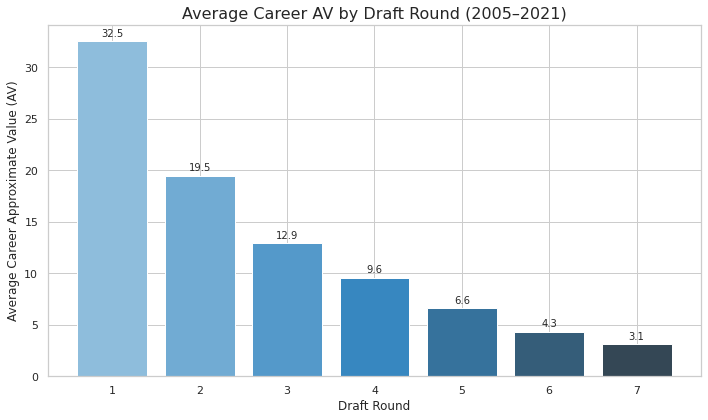

 round  avg_career_av
     1      32.514760
     2      19.487985
     3      12.899514
     4       9.589540
     5       6.614887
     6       4.293853
     7       3.118881


In [15]:
# Calculate average career AV per round
av_by_round = analysis_df.groupby('round')['career_av'].mean().reset_index()
av_by_round.columns = ['round', 'avg_career_av']

# Bar chart of average career AV by round
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(av_by_round['round'], av_by_round['avg_career_av'],
              color=sns.color_palette("Blues_d", len(av_by_round)))

ax.set_title('Average Career AV by Draft Round (2005–2021)', fontsize=16)
ax.set_xlabel('Draft Round', fontsize=12)
ax.set_ylabel('Average Career Approximate Value (AV)', fontsize=12)
ax.set_xticks(av_by_round['round'])

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 0.3,
            f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(av_by_round.to_string(index=False))

### Observation: Diminishing Returns After Round 2

The drop in average career AV between rounds tells an interesting story.
The gap between Round 1 (32.5) and Round 2 (19.5) is 13.0 AV points —
by far the largest single-round drop. By contrast, the difference between
a Round 3 (12.9) and Round 4 (9.6) pick is only 3.3 points, and rounds
4 through 7 are remarkably close together. This suggests that while
securing a first round pick is highly valuable, teams may be overvaluing
the difference between mid-to-late round selections. The real premium in
the NFL Draft lies in round 1 — everything after round 2 offers
diminishing returns.

### Average Career AV by Pick Number

Now we drill down further — within round 1, does the exact pick number
matter? We smooth the data using a rolling average to better visualize
the trend across all ~260 picks per draft.

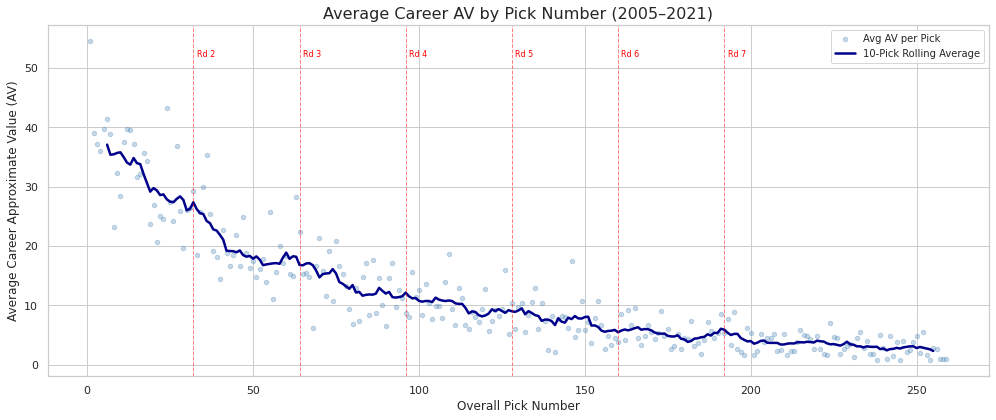

In [16]:
# Calculate average career AV per pick number
av_by_pick = analysis_df.groupby('pick')['career_av'].mean().reset_index()
av_by_pick.columns = ['pick', 'avg_career_av']

# Apply a rolling average to smooth the trend line
av_by_pick['rolling_avg'] = av_by_pick['avg_career_av'].rolling(window=10, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Raw averages as scatter
ax.scatter(av_by_pick['pick'], av_by_pick['avg_career_av'],
           alpha=0.3, color='steelblue', s=20, label='Avg AV per Pick')

# Smoothed trend line
ax.plot(av_by_pick['pick'], av_by_pick['rolling_avg'],
        color='darkblue', linewidth=2.5, label='10-Pick Rolling Average')

# Highlight the round boundaries
round_boundaries = [32, 64, 96, 128, 160, 192]
for boundary in round_boundaries:
    ax.axvline(x=boundary, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(boundary + 1, av_by_pick['avg_career_av'].max() * 0.95,
            f'Rd {round_boundaries.index(boundary) + 2}',
            color='red', fontsize=8)

ax.set_title('Average Career AV by Pick Number (2005–2021)', fontsize=16)
ax.set_xlabel('Overall Pick Number', fontsize=12)
ax.set_ylabel('Average Career Approximate Value (AV)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Observation: Pick-Level Analysis Reveals Three Distinct Zones

The pick-by-pick chart reveals three distinct zones of draft value:

- **Zone 1 (Picks 1–32, Round 1):** High average AV but also high variance.
  The best players in our dataset came from this range, but so did many busts.
  Teams selecting here are betting on a high ceiling, not a guaranteed outcome.

- **Zone 2 (Picks 33–96, Rounds 2–3):** A steady decline in average AV with
  noticeably less variance. These picks are more predictable — unlikely to
  produce a superstar, but also unlikely to be a complete bust.

- **Zone 3 (Picks 97+, Rounds 4–7):** The rolling average flatlines near
  5–8 AV for the remaining 160+ picks. From a pure value standpoint, trading
  a 4th round pick for a 6th round pick is essentially meaningless — the
  expected output is nearly identical.

This finding has major implications for how teams should approach draft
day trades — the premium should be heavily concentrated on round 1 picks,
particularly the top 10.

## Analysis Part 2: Which NFL Teams Draft Best?

Now that we understand the expected career AV by pick number, we can evaluate
each NFL team's drafting efficiency. The core idea is simple:

- Every pick has an **expected AV** based on its position (from Part 1)
- Every pick has an **actual AV** based on what the player achieved
- The difference between actual and expected is the team's **draft surplus**

A positive surplus means a team consistently got more than expected from
their picks. A negative surplus means they underperformed expectations.
This approach is fair because it accounts for pick position — a team that
drafts well in the late rounds gets credit even if their overall AV is low.

In [17]:
# Step 1: Calculate expected AV for each pick number
# This is the historical average AV for that pick position (from Part 1)
expected_av = analysis_df.groupby('pick')['career_av'].mean().reset_index()
expected_av.columns = ['pick', 'expected_av']

# Step 2: Merge expected AV back onto the main DataFrame
analysis_df = analysis_df.merge(expected_av, on='pick', how='left')

# Step 3: Calculate draft surplus for each pick
# Surplus = actual career AV - expected AV for that pick
analysis_df['surplus'] = analysis_df['career_av'] - analysis_df['expected_av']

print("Sample of surplus calculations:")
analysis_df[['player', 'team', 'pick', 'career_av', 'expected_av', 'surplus']].head(10)

Sample of surplus calculations:


,player,team,pick,career_av,expected_av,surplus
0,Alex Smith,SFO,1,28.0,54.588235,-26.588235
1,Ronnie Brown,MIA,2,36.0,39.058824,-3.058824
2,Braylon Edwards,CLE,3,27.0,37.176471,-10.176471
3,Cedric Benson,CHI,4,10.0,36.058824,-26.058824
4,Cadillac Williams,TAM,5,27.0,39.647059,-12.647059
5,Adam Jones,TEN,6,13.0,41.352941,-28.352941
6,Troy Williamson,MIN,7,8.0,38.941176,-30.941176
7,Antrel Rolle,ARI,8,20.0,23.117647,-3.117647
8,Carlos Rogers,WAS,9,26.0,32.352941,-6.352941
9,Mike Williams,DET,10,4.0,28.352941,-24.352941


### Team Drafting Efficiency Rankings

We now aggregate surplus by team to find which franchises have
consistently over or underperformed their draft position expectations
over the 2005–2021 window.

In [18]:
# Aggregate surplus by team
team_efficiency = analysis_df.groupby('team').agg(
    total_picks=('pick', 'count'),
    avg_career_av=('career_av', 'mean'),
    avg_expected_av=('expected_av', 'mean'),
    avg_surplus=('surplus', 'mean'),
    total_surplus=('surplus', 'sum')
).reset_index()

# Sort by average surplus
team_efficiency = team_efficiency.sort_values('avg_surplus', ascending=False).reset_index(drop=True)

print(team_efficiency.to_string(index=False))

team  total_picks  avg_career_av  avg_expected_av  avg_surplus  total_surplus
 GNB          158      14.265823        10.818973     3.446849     544.602206
 ATL          126      14.500000        11.995547     2.504453     315.561029
 DAL          140      13.885714        11.381545     2.504169     350.583710
 NOR          103      15.582524        13.455682     2.126842     219.064706
 PIT          139      12.611511        10.655555     1.955956     271.877828
 KAN          129      14.162791        12.245417     1.917373     247.341176
 SEA          145      11.951724        10.602060     1.349665     195.701357
 PHI          144      12.680556        11.416258     1.264297     182.058824
 BAL          147      12.789116        11.676671     1.112445     163.529412
 IND          139      11.769784        10.958332     0.811452     112.791799
 LAC          116      13.784483        13.106491     0.677992      78.647059
 MIN          153      11.627451        11.039047     0.588403  

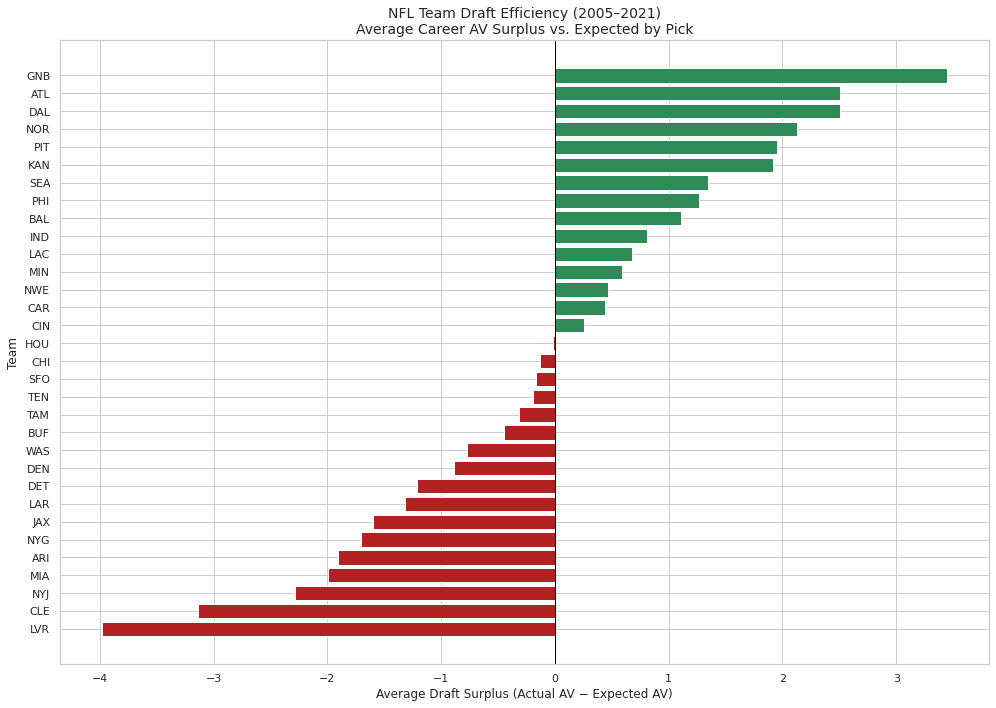

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))

# Color bars green for positive surplus, red for negative
colors = ['seagreen' if x >= 0 else 'firebrick' for x in team_efficiency['avg_surplus']]

bars = ax.barh(team_efficiency['team'], team_efficiency['avg_surplus'], color=colors)

# Add a vertical line at 0 for reference
ax.axvline(x=0, color='black', linewidth=1)

ax.set_title('NFL Team Draft Efficiency (2005–2021)\nAverage Career AV Surplus vs. Expected by Pick', fontsize=14)
ax.set_xlabel('Average Draft Surplus (Actual AV − Expected AV)', fontsize=12)
ax.set_ylabel('Team', fontsize=12)

# Invert y-axis so best team is at top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
print("=== TOP 5 DRAFTING TEAMS (2005-2021) ===")
print(team_efficiency[['team', 'total_picks', 'avg_career_av',
                        'avg_expected_av', 'avg_surplus']].head(5).to_string(index=False))

print("\n=== BOTTOM 5 DRAFTING TEAMS (2005-2021) ===")
print(team_efficiency[['team', 'total_picks', 'avg_career_av',
                        'avg_expected_av', 'avg_surplus']].tail(5).to_string(index=False))

=== TOP 5 DRAFTING TEAMS (2005-2021) ===
team  total_picks  avg_career_av  avg_expected_av  avg_surplus
 GNB          158      14.265823        10.818973     3.446849
 ATL          126      14.500000        11.995547     2.504453
 DAL          140      13.885714        11.381545     2.504169
 NOR          103      15.582524        13.455682     2.126842
 PIT          139      12.611511        10.655555     1.955956

=== BOTTOM 5 DRAFTING TEAMS (2005-2021) ===
team  total_picks  avg_career_av  avg_expected_av  avg_surplus
 ARI          122      10.573770        12.479475    -1.905704
 MIA          134      10.858209        12.851624    -1.993415
 NYJ          121      10.380165        12.667477    -2.287312
 CLE          143       9.944056        13.077746    -3.133690
 LVR          136       8.860294        12.840820    -3.980526


### Observation: Top and Bottom Drafting Franchises

The results reveal some clear patterns among the best and worst drafting
teams from 2005–2021:

**Best Drafters:** Green Bay leads all teams with an average surplus of +3.4 AV
per pick — consistent with their philosophy of building exclusively through
the draft. Pittsburgh and New Orleans also appear, both franchises renowned
for developing players beyond their draft slot expectations.

**Worst Drafters:** The Raiders (LVR) rank dead last at -4.0 AV per pick,
reflecting years of questionable selections under previous ownership and
coaching staff. Cleveland (-3.1) is similarly unsurprising given their
well-documented struggles with top picks during this era. The Jets (-2.3)
and Dolphins (-2.0) round out a disappointing AFC East contingent.

**An important caveat:** Teams that consistently pick early (bad teams) face
higher expectations per pick in our model, which can inflate their negative
surplus. Cleveland and the Raiders both fit this profile — frequent top-10
picks carry the highest expectations and hurt most when they bust.

## Analysis Part 3: Which Position is Most Likely to Bust?

A "bust" in NFL terms is a player who was drafted with high expectations
but failed to deliver meaningful production. For our purposes, we define
a bust as any player drafted in rounds 1 or 2 (where expectations are
highest) who finished their career with a career AV of 10 or less —
indicating they made little to no meaningful impact at the NFL level.

We focus on rounds 1 and 2 because busting in later rounds carries far
less cost to a franchise — the real damage comes from wasting premium
draft capital on a player who never pans out.

In [23]:
# Define busts as round 1 or 2 picks with career AV of 10 or less
early_picks = analysis_df[analysis_df['round'] <= 2].copy()
early_picks['bust'] = early_picks['career_av'] <= 10

# Consolidate all offensive line positions into 'OL'
ol_positions = ['T', 'G', 'C', 'OL', 'OT', 'OG']
analysis_df['position'] = analysis_df['position'].replace({pos: 'OL' for pos in ol_positions})
early_picks['position'] = early_picks['position'].replace({pos: 'OL' for pos in ol_positions})

# Verify the consolidation worked
print("Offensive line positions after consolidation:")
print(early_picks[early_picks['position'] == 'OL']['position'].value_counts())
print("\nAll positions remaining:")
print(sorted(early_picks['position'].unique()))

# Calculate bust rate by position
bust_by_position = early_picks.groupby('position').agg(
    total_picked=('bust', 'count'),
    total_busts=('bust', 'sum'),
    bust_rate=('bust', 'mean')
).reset_index()

# Filter to positions with at least 10 picks to avoid small sample sizes
bust_by_position = bust_by_position[bust_by_position['total_picked'] >= 10]
bust_by_position['bust_rate_pct'] = (bust_by_position['bust_rate'] * 100).round(1)
bust_by_position = bust_by_position.sort_values('bust_rate', ascending=False).reset_index(drop=True)

print(bust_by_position.to_string(index=False))

Offensive line positions after consolidation:
OL    186
Name: position, dtype: int64

All positions remaining:
['CB', 'DB', 'DE', 'DL', 'DT', 'ILB', 'K', 'LB', 'NT', 'OL', 'OLB', 'QB', 'RB', 'S', 'TE', 'WR']
position  total_picked  total_busts  bust_rate  bust_rate_pct
      CB            55           27   0.490909           49.1
      WR           143           51   0.356643           35.7
      TE            44           15   0.340909           34.1
      DE           112           35   0.312500           31.2
      QB            72           22   0.305556           30.6
      DT            82           24   0.292683           29.3
     OLB            22            6   0.272727           27.3
      LB           103           26   0.252427           25.2
      DB           130           32   0.246154           24.6
      RB            80           19   0.237500           23.8
       S            34            8   0.235294           23.5
      OL           186           26   0.139785  

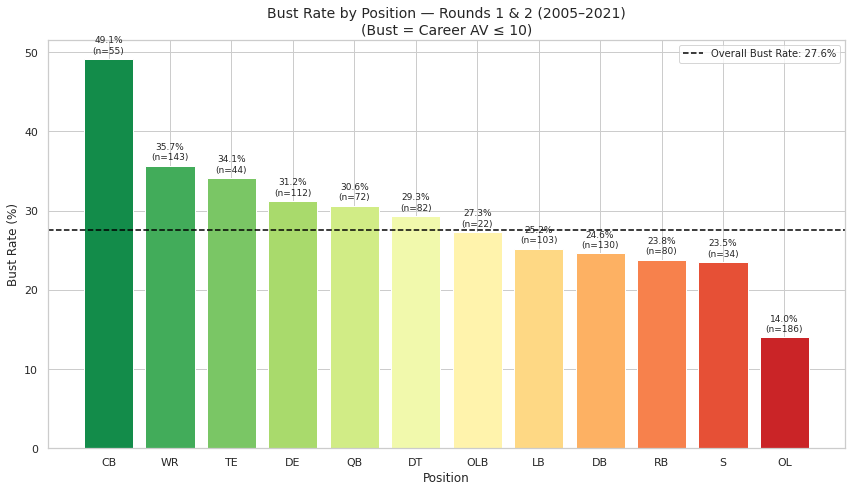

In [24]:
fig, ax = plt.subplots(figsize=(12, 7))

# Color bars by bust rate — higher bust rate = darker red
colors = sns.color_palette("RdYlGn_r", len(bust_by_position))

bars = ax.bar(bust_by_position['position'],
              bust_by_position['bust_rate_pct'],
              color=colors)

# Add value labels on top of each bar
for bar, rate, total in zip(bars,
                             bust_by_position['bust_rate_pct'],
                             bust_by_position['total_picked']):
    ax.text(bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.5,
            f'{rate}%\n(n={total})',
            ha='center', va='bottom', fontsize=9)

# Add a horizontal reference line at the overall bust rate
overall_bust_rate = early_picks['bust'].mean() * 100
ax.axhline(y=overall_bust_rate, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall Bust Rate: {overall_bust_rate:.1f}%')

ax.set_title('Bust Rate by Position — Rounds 1 & 2 (2005–2021)\n(Bust = Career AV ≤ 10)', fontsize=14)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Bust Rate (%)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Average Career AV by Position

Beyond bust rates, let's also look at which positions tend to produce
the highest career AV when drafted early. This tells us not just where
busts happen, but where the hits are most valuable.

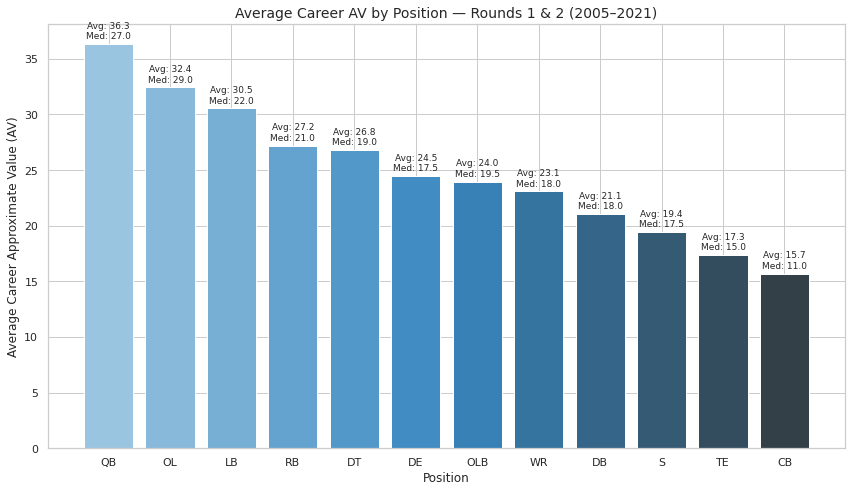

In [26]:
# Average career AV by position for early picks
av_by_position = early_picks.groupby('position').agg(
    total_picked=('career_av', 'count'),
    avg_career_av=('career_av', 'mean'),
    median_career_av=('career_av', 'median')
).reset_index()

av_by_position = av_by_position[av_by_position['total_picked'] >= 10]
av_by_position = av_by_position.sort_values('avg_career_av', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

colors = sns.color_palette("Blues_d", len(av_by_position))

bars = ax.bar(av_by_position['position'],
              av_by_position['avg_career_av'],
              color=colors)

for bar, avg, med in zip(bars,
                          av_by_position['avg_career_av'],
                          av_by_position['median_career_av']):
    ax.text(bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.3,
            f'Avg: {avg:.1f}\nMed: {med:.1f}',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Average Career AV by Position — Rounds 1 & 2 (2005–2021)', fontsize=14)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Average Career Approximate Value (AV)', fontsize=12)

plt.tight_layout()
plt.show()

### Observation: Position Bust Rates and Career AV Combined

Together, the bust rate and average career AV charts paint a clear picture
of which positions are the safest and riskiest investments in rounds 1 and 2:

**Riskiest Positions to Draft Early:**
- **CB (49.1% bust rate, avg AV 15.7):** Cornerback is by far the riskiest
  early round investment. Nearly 1 in 2 early CB picks bust, and even the
  hits produce the lowest average AV of any position. Teams should think
  twice before spending a top pick here.
- **WR (35.7% bust rate, avg AV 23.1):** Wide receiver has the second
  highest bust rate despite being one of the most frequently drafted
  positions early. The college-to-pro transition at receiver is clearly
  harder than teams anticipate.
- **TE (34.1% bust rate, avg AV 19.4):** Tight end is notoriously slow
  to develop, which likely contributes to its high bust rate despite
  the position's importance in modern offenses.

**Safest Positions to Draft Early:**
- **OL (14.0% bust rate, avg AV 32.4):** Offensive line is the single
  safest early round investment by a wide margin — the lowest bust rate
  AND the second highest average AV. Elite offensive linemen consistently
  deliver value and rarely bust when selected early.
- **S (23.5% bust rate, avg AV 21.1):** Safety is a quietly reliable
  early round pick, with a below average bust rate and solid career AV.
- **RB (24.6% bust rate, avg AV 27.2):** Despite the modern NFL's
  shift away from premium RB investment, early round running backs
  still produce at a solid clip when drafted in rounds 1 and 2.

**The QB Paradox:**
- QB sits right at the overall bust rate (30.6%) but has the highest
  average AV (36.3) of any position. This reflects the extreme variance
  at the position — when a QB hits, they hit bigger than anyone else,
  but roughly 1 in 3 early QB picks still fail to pan out. The average
  is heavily inflated by a handful of elite franchise quarterbacks.

## Conclusions

This analysis set out to answer two core questions: does draft position
predict NFL success, and which teams and positions offer the best and
worst return on draft investment? After analyzing 5,109 picks across
20 NFL Drafts (2005–2021), here is what we found:

---

### Finding 1: Draft Position Matters — But Mostly in Round 1

The data confirms that earlier picks do produce better players on average,
but the relationship is far from linear. The most important finding is that
the real premium in the NFL Draft is concentrated almost entirely in round 1.
The drop from round 1 (avg AV: 32.5) to round 2 (avg AV: 19.5) is the
largest single step down in the entire draft. After round 2, the differences
between rounds become increasingly marginal — rounds 4 through 7 are nearly
interchangeable in terms of expected output.

**Implication:** Teams should be extremely reluctant to trade away first
round picks. Trading multiple mid-to-late round picks to move up within
round 1 can be justified, but trading a first rounder for anything outside
round 1 is very difficult to justify based on the data.

---

### Finding 2: Drafting Consistency Separates Good Teams from Bad Ones

Green Bay led all 32 franchises with an average surplus of +3.4 AV per
pick — meaning they consistently got more out of their picks than expected
regardless of where they selected. Pittsburgh, New Orleans, Atlanta and
Dallas rounded out the top 5, all franchises with reputations for player
development and scouting excellence.

At the other end, the Raiders (-4.0) and Browns (-3.1) were the worst
drafting teams of the era — both franchises well known for years of
organizational dysfunction that extended into their draft rooms. The Jets
and Dolphins also underperformed significantly.

**Implication:** Drafting well is a repeatable organizational skill, not
luck. The same franchises appear at the top and bottom of these rankings
year after year, suggesting that scouting infrastructure, coaching, and
player development culture have a measurable impact on draft outcomes.

---

### Finding 3: Position Matters as Much as Pick Number

Perhaps the most actionable finding of this analysis is how dramatically
bust rates vary by position. Cornerback (49.1% bust rate) and wide receiver
(35.7%) are by far the riskiest early round investments, while offensive
line (14.0%) is the safest by a significant margin. OL also ranks second
in average career AV (32.4), making it both the lowest risk and highest
reward position group in the early rounds.

**Implication:** Teams that consistently spend early picks on CB and WR
are taking on significantly more risk than those who invest in the trenches.
The data suggests the NFL may be systematically overvaluing skill positions
in the draft relative to offensive linemen.

---

### Limitations and Future Work

It is important to acknowledge several limitations of this analysis:

- **Career AV is an approximation** — it is not a perfect metric and
  can undervalue some positions (particularly offensive linemen and
  defensive backs) relative to skill positions
- **Recent picks are excluded** — players drafted 2022–2024 were removed
  since they have not had enough time to accumulate career AV, which means
  our team rankings may not reflect recent drafting improvements or declines
- **Sample size varies by position** — some positions (OLB, C) have small
  sample sizes in rounds 1 and 2 which makes their bust rates less reliable
- **Team context matters** — a player's AV is influenced by their
  supporting cast, coaching, and opportunities, not just their own ability

Future analysis could incorporate combine measurables, college production
metrics, or coaching staff data to build a more complete picture of what
separates draft hits from busts.

In [27]:
# Final summary statistics
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)
print(f"Draft years analyzed:        2005–2021")
print(f"Total picks analyzed:        {len(analysis_df)}")
print(f"Overall bust rate (Rds 1-2): {early_picks['bust'].mean()*100:.1f}%")
print(f"Best drafting team:          {team_efficiency.iloc[0]['team']} ({team_efficiency.iloc[0]['avg_surplus']:+.2f} avg surplus)")
print(f"Worst drafting team:         {team_efficiency.iloc[-1]['team']} ({team_efficiency.iloc[-1]['avg_surplus']:+.2f} avg surplus)")
print(f"Safest position to draft:    OL ({bust_by_position[bust_by_position['position']=='OL']['bust_rate_pct'].values[0]}% bust rate)")
print(f"Riskiest position to draft:  CB ({bust_by_position[bust_by_position['position']=='CB']['bust_rate_pct'].values[0]}% bust rate)")
print("=" * 50)

ANALYSIS SUMMARY
Draft years analyzed:        2005–2021
Total picks analyzed:        4331
Overall bust rate (Rds 1-2): 27.6%
Best drafting team:          GNB (+3.45 avg surplus)
Worst drafting team:         LVR (-3.98 avg surplus)
Safest position to draft:    OL (14.0% bust rate)
Riskiest position to draft:  CB (49.1% bust rate)


## Data Sources

The data used in this analysis was sourced from **Pro Football Reference**
(https://www.pro-football-reference.com/), one of the most comprehensive
and widely cited NFL statistics databases available.

Specifically, we used the annual NFL Draft pages for each year from 2005
to 2024, which can be found at: https://www.pro-football-reference.com/draft/{YEAR}-draft.htm
